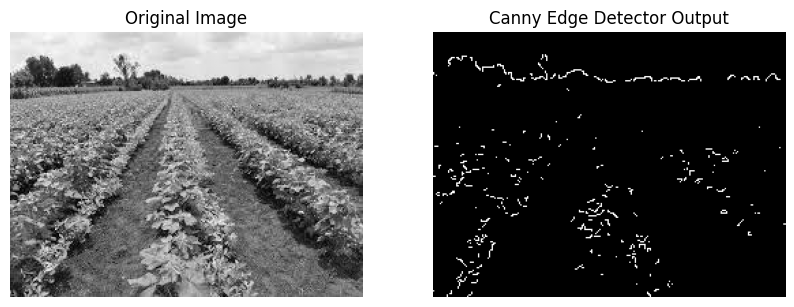

Estimated crop field angle (Least-Squares): -4.52 degrees


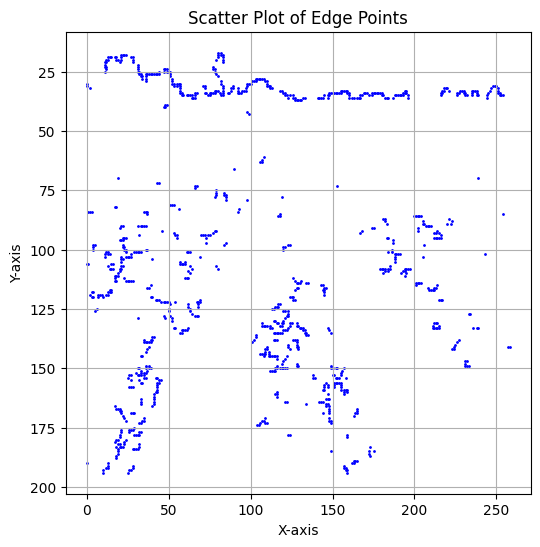

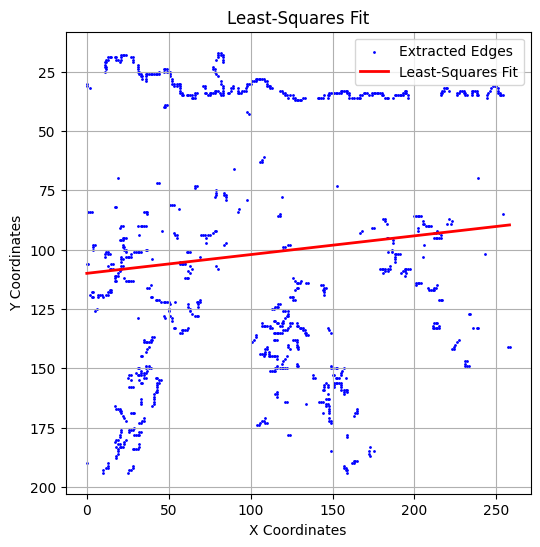

Estimated crop field angle (Total Least-Squares): -10.38 degrees


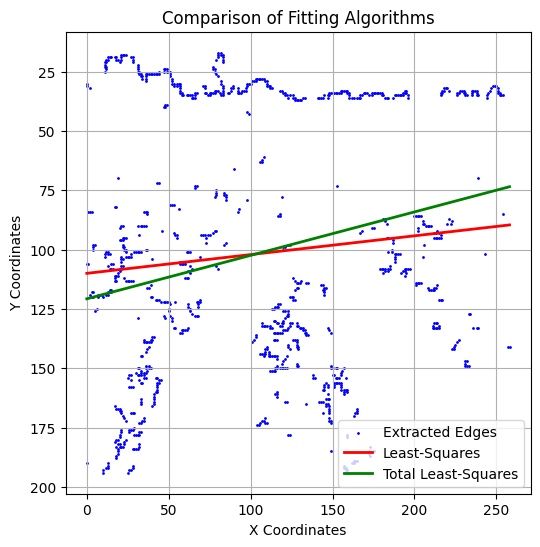

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('../Images/img1.jpg',0)

assert img is not None

edges = cv.Canny(img,550,690)
    
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges,cmap='gray')
plt.title('Canny Edge Detector Output')
plt.axis('off')

plt.show()

#Extracting the coordinates of edge points

indices = np.where(edges != 0)

x=indices[1]
y=indices[0]

plt.figure(figsize=(6,6))

plt.scatter(x,y,s=1, color='blue')

plt.gca().invert_yaxis()

plt.title('Scatter Plot of Edge Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)

m, c = np.polyfit(x, y, 1)

x_line = np.array([min(x), max(x)])
y_line = m * x_line + c

angle_rad = np.arctan(m)
angle_deg = np.degrees(angle_rad)

print(f"Estimated crop field angle (Least-Squares): {angle_deg:.2f} degrees")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, color='blue', label='Extracted Edges')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Least-Squares Fit')
plt.gca().invert_yaxis()

plt.title('Least-Squares Fit')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.legend()
plt.grid(True)

plt.show()

x_mean = np.mean(x)
y_mean = np.mean(y)

x_centered = x - x_mean
y_centered = y - y_mean

data_matrix = np.vstack((x_centered, y_centered)).T
U, S, V_transpose = np.linalig.svd(data_matrix)

direction_vector = V_transpose[0]
dx = direction_vector[0]
dy = direction_vector[1]

m_tls = dy/dx
c_tls = y_mean - (m_tls * x_mean)]
;